In [8]:
import pickle
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _is_nan_like(x):
    """Check for NaN-like values (np.nan, None, or 'nan' strings)."""
    if x is None:
        return True
    if isinstance(x, float) and np.isnan(x):
        return True
    if isinstance(x, str) and x.strip().lower() in {"nan", "none", ""}:
        return True
    return False

def load_dlst(pkl_path: str):
    """Load D_lst from a pickle file."""
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

def load_act_context_from_xlsx(xlsx_path: str, sheet_name="ActionLst"):
    """
    Load activity context definitions from Excel file.
    Expected columns: actID, qID, act_C_T1..3, act_C_P1..3
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name).replace(-1, np.nan)
    needed = ["actID", "qID", "act_C_T1", "act_C_T2", "act_C_T3", "act_C_P1", "act_C_P2", "act_C_P3"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in context xlsx: {missing}")

    # Build dictionary with activity context data
    dc = {}
    for _, r in df.iterrows():
        act = str(r["actID"])
        dc[act] = {
            "qID": str(r["qID"]) if not _is_nan_like(r["qID"]) else None,
            "act_C_T1": r["act_C_T1"],
            "act_C_T2": r["act_C_T2"],
            "act_C_T3": r["act_C_T3"],
            "act_C_P1": r["act_C_P1"],
            "act_C_P2": r["act_C_P2"],
            "act_C_P3": r["act_C_P3"],
        }
    return dc


In [9]:
def qc_dlst_notebook(D_lst, r_T=0.3, actID_context_dc=None, label="D_lst"):
    """
    Quality check for D_lst data.
    Returns: summary dict, issues dataframe, duplicates dataframe, context dataframes, and ratings list.
    """

    issues = []
    user_counts = Counter()
    item_counts = Counter()
    seq_len_counts = Counter()
    ratings = []

    # Context-related counters
    ctx_time_vals = Counter()
    ctx_place_vals = Counter()
    ctx_missing_rows = 0
    ctx_mismatch_rows = 0

    # Track duplicates: (uID, item_str) -> [(idx, rating)]
    seen = defaultdict(list)

    def item_to_str(item):
        if isinstance(item, tuple):
            return "|".join(map(str, item))
        return str(item)

    for idx, row in enumerate(D_lst):
        if not isinstance(row, (list, tuple)) or len(row) < 4:
            issues.append({"idx": idx, "type": "bad_row_shape", "detail": f"{row}"})
            continue

        uID, act_seq, ctx_seq, rating = row[0], row[1], row[2], row[3]

        # Validate user ID
        if _is_nan_like(uID):
            issues.append({"idx": idx, "type": "bad_uID", "detail": f"uID={uID}"})

        # Validate action sequence
        if not isinstance(act_seq, tuple) or len(act_seq) == 0:
            issues.append({"idx": idx, "type": "bad_act_seq", "detail": f"act_seq={act_seq}"})
            continue

        # Validate rating
        if not isinstance(rating, (int, float)) or (isinstance(rating, float) and np.isnan(rating)):
            issues.append({"idx": idx, "type": "bad_rating", "detail": f"rating={rating}"})
        else:
            rating_f = float(rating)
            ratings.append(rating_f)

            if rating_f < r_T - 1e-9:
                issues.append({"idx": idx, "type": "rating_below_threshold", "detail": f"rating={rating_f}, r_T={r_T}"})
            if rating_f > 5.0 + 1e-6:
                issues.append({"idx": idx, "type": "rating_above_5", "detail": f"rating={rating_f}"})

        # Update counters
        user_counts[uID] += 1
        item_str = item_to_str(act_seq)
        item_counts[item_str] += 1
        seq_len_counts[len(act_seq)] += 1

        # Track duplicates
        seen[(uID, item_str)].append((idx, rating))

        # Validate context sequence
        if ctx_seq is None or (isinstance(ctx_seq, tuple) and len(ctx_seq) == 0):
            ctx_missing_rows += 1
        else:
            # Expect tuple of dicts with same length as act_seq
            if not (isinstance(ctx_seq, tuple) and len(ctx_seq) == len(act_seq) and all(isinstance(d, dict) for d in ctx_seq)):
                issues.append({"idx": idx, "type": "bad_context_shape", "detail": f"type={type(ctx_seq)}, len={getattr(ctx_seq,'__len__',lambda:None)()}"})
            else:
                for a_i, act in enumerate(act_seq):
                    c = ctx_seq[a_i]

                    # Collect time and place context values
                    for k in ["C_T1", "C_T2", "C_T3"]:
                        v = c.get(k, None)
                        if not _is_nan_like(v):
                            ctx_time_vals[str(v).strip().lower()] += 1

                    for k in ["C_P1", "C_P2", "C_P3"]:
                        v = c.get(k, None)
                        if not _is_nan_like(v):
                            ctx_place_vals[str(v).strip().lower()] += 1

                    # Cross-check with activity context dictionary (optional)
                    if actID_context_dc is not None:
                        act_key = act[0] if isinstance(act, tuple) else str(act)
                        if act_key not in actID_context_dc:
                            issues.append({"idx": idx, "type": "missing_act_in_context_dc", "detail": f"act={act_key}"})
                            ctx_mismatch_rows += 1
                        else:
                            ref = actID_context_dc[act_key]
                            q_ref = ref.get("qID", None)
                            q_row = c.get("qID", None)
                            if (q_ref is not None) and (q_row is not None) and (str(q_ref) != str(q_row)):
                                issues.append({"idx": idx, "type": "qID_mismatch", "detail": f"act={act_key}, ref={q_ref}, row={q_row}"})
                                ctx_mismatch_rows += 1

    # Build duplicates dataframe
    dup_rows = []
    for (uID, item_str), idx_r_list in seen.items():
        if len(idx_r_list) > 1:
            rs = [float(r) for _, r in idx_r_list if isinstance(r, (int, float))]
            dup_rows.append({
                "uID": uID,
                "item": item_str,
                "n_dups": len(idx_r_list),
                "ratings_min": np.min(rs) if rs else np.nan,
                "ratings_max": np.max(rs) if rs else np.nan,
                "idxs_sample": [i for i, _ in idx_r_list[:10]],
            })

    # Build summary statistics
    summary = {
        "label": label,
        "n_rows": len(D_lst),
        "n_users": len(user_counts),
        "n_items": len(item_counts),
        "seq_len_dist": dict(seq_len_counts),
        "rating_min": float(np.min(ratings)) if ratings else np.nan,
        "rating_max": float(np.max(ratings)) if ratings else np.nan,
        "rating_mean": float(np.mean(ratings)) if ratings else np.nan,
        "rating_std": float(np.std(ratings)) if ratings else np.nan,
        "users_min_rows": int(min(user_counts.values())) if user_counts else 0,
        "users_max_rows": int(max(user_counts.values())) if user_counts else 0,
        "items_min_rows": int(min(item_counts.values())) if item_counts else 0,
        "items_max_rows": int(max(item_counts.values())) if item_counts else 0,
        "ctx_missing_rows": int(ctx_missing_rows),
        "ctx_mismatch_rows": int(ctx_mismatch_rows),
        "n_issues": len(issues),
        "n_duplicate_user_item": len(dup_rows),
        "n_unique_time_values": len(ctx_time_vals),
        "n_unique_place_values": len(ctx_place_vals),
    }

    issues_df = pd.DataFrame(issues).sort_values(["type", "idx"]) if issues else pd.DataFrame(columns=["idx","type","detail"])
    duplicates_df = pd.DataFrame(dup_rows).sort_values(["n_dups","uID"], ascending=[False, True]) if dup_rows else pd.DataFrame(columns=["uID","item","n_dups","ratings_min","ratings_max","idxs_sample"])

    ctx_time_df = pd.DataFrame(ctx_time_vals.most_common(50), columns=["time_value", "count"])
    ctx_place_df = pd.DataFrame(ctx_place_vals.most_common(50), columns=["place_value", "count"])

    return summary, issues_df, duplicates_df, ctx_time_df, ctx_place_df, ratings


Loading: D_lst_full_20260202_150312.pkl


,value
label,D_lst_full_20260202_150312.pkl
n_rows,3053029
n_users,679
n_items,6579
seq_len_dist,"{1: 8312, 2: 216804, 3: 2827913}"
rating_min,0.3
rating_max,5.0
rating_mean,1.54134
rating_std,0.839723
users_min_rows,342


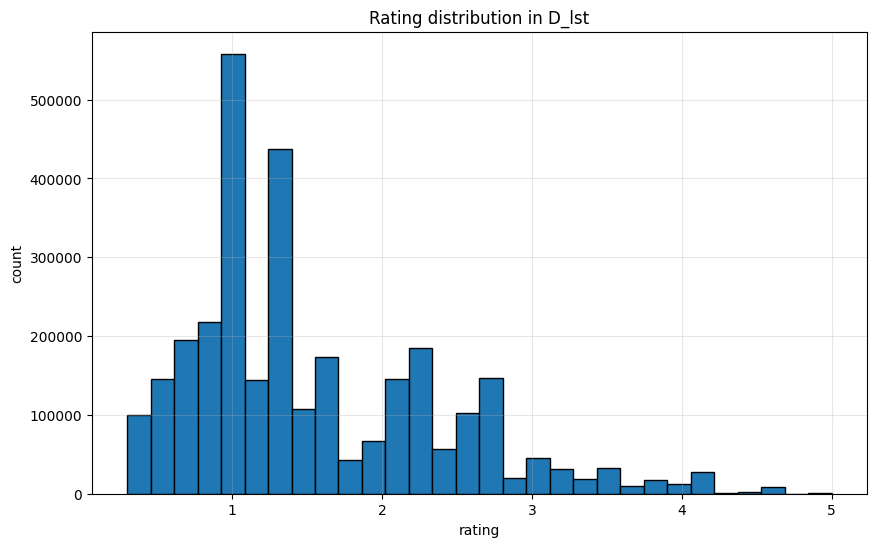


Top time values:


,time_value,count
0,dopoldne,3645383
1,popoldne,3199109
2,zjutraj,2894151
3,podnevi,2112388
4,kadarkoli,1278635
5,ob kosilu,1056194
6,zvečer,974371
7,ob zajtrku,528097
8,ob večerji,528097
9,malica dopoldne,304962



Top place values:


,place_value,count
0,kjerkoli,5636961
1,v telovadnici,1864113
2,doma,1727418
3,v naravi,1344010
4,v gozdu,459922
5,v mestu,459922
6,v parku,446274
7,na sprehodu,229961
8,v naselju,229961



Issue types (top 10):
No issues found ✅

Sample issues (first 30):


,idx,type,detail



Duplicate (uID,item) pairs:


,uID,item,n_dups,ratings_min,ratings_max,idxs_sample


In [10]:
# 1) Load D_lst dataset
dlst_path = Path(r"C:\Users\gl8304\Documents\Projekti\Faks\Thesis\data\D_lst\D_lst_full_20260202_150312.pkl")

if not dlst_path.exists():
    raise FileNotFoundError(f"D_lst file not found: {dlst_path}")

print(f"Loading: {dlst_path.name}")
D_lst = load_dlst(str(dlst_path))

# 2) (Optional) Load reference context for cross-check
# context_xlsx = Path.cwd().parent / "data" / "ActivityContextGen_v11.xlsx"
# if context_xlsx.exists():
#     act_ctx = load_act_context_from_xlsx(str(context_xlsx), sheet_name="ActionLst")
# else:
#     act_ctx = None
act_ctx = None  # Set to None if cross-check is not needed

# 3) Run quality check
summary, issues_df, duplicates_df, ctx_time_df, ctx_place_df, ratings = qc_dlst_notebook(
    D_lst,
    r_T=0.3,
    actID_context_dc=act_ctx,
    label=dlst_path.name if dlst_path else "D_lst"
)

# 4) Display summary statistics
summary_df = pd.DataFrame([summary]).T
summary_df.columns = ["value"]
display(summary_df)

# 5) Plot: rating distribution
plt.figure(figsize=(10, 6))
plt.hist(ratings, bins=30, edgecolor='black')
plt.title("Rating distribution in D_lst")
plt.xlabel("rating")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

# 6) Display most common time/place contexts
print("\nTop time values:")
display(ctx_time_df.head(20))

print("\nTop place values:")
display(ctx_place_df.head(20))

# 7) Show issues and duplicates (if any)
print("\nIssue types (top 10):")
if not issues_df.empty:
    display(issues_df["type"].value_counts().head(10).to_frame("count"))
else:
    print("No issues found ✅")

print("\nSample issues (first 30):")
display(issues_df.head(30))

print("\nDuplicate (uID,item) pairs:")
display(duplicates_df.head(30))


In [11]:
# Calculate sparsity metrics
n_users = len(set(x[0] for x in D_lst))
n_items = len(set(x[1] for x in D_lst))
n_ratings = len(D_lst)

density = n_ratings / (n_users * n_items)
sparsity = 1 - density

print(f"Users: {n_users}")
print(f"Items: {n_items}")
print(f"Ratings: {n_ratings}")
print(f"Density: {density:.4f}")
print(f"Sparsity: {sparsity:.4%}")


Users: 679
Items: 6579
Ratings: 3053029
Density: 0.6834
Sparsity: 31.6559%


In [12]:
# Sparsity analysis - compile all unique actions from D_lst
all_actions = set()
for row in D_lst:
    if len(row) >= 2 and isinstance(row[1], tuple):  # act_seq is a tuple
        all_actions.update(row[1])

n_users = len(set(x[0] for x in D_lst if len(x) >= 1))
n_all_actions = len(all_actions)  # all unique actions from D_lst
n_observed = len(set((x[0], x[1]) for x in D_lst if len(x) >= 2))  # (user, action_seq) pairs

if n_users > 0 and n_all_actions > 0:
    density = n_observed / (n_users * n_all_actions)
    sparsity = 1 - density
    print(f"Users: {n_users}")
    print(f"All actions: {n_all_actions}")
    print(f"Observed (user, action_seq): {n_observed}")
    print(f"Sparsity (conceptual): {sparsity:.2%}")
else:
    print("Error: No data or incorrect data structure")


Users: 679
All actions: 34
Observed (user, action_seq): 3053029
Sparsity (conceptual): -13124.59%
